In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.integrate import quad
from astropy.table import Table
import random
from tqdm import tqdm
from scipy.integrate import dblquad
random.seed(15)
np.random.seed(15)

# .evt install
hdul = fits.open('/home/yu/XRT/GRB190823A/processed_data/20934/sw00020934002xpcw3po_cl.evt')
hdul.info()
BADPIX = hdul['BADPIX'].data
EVENTS = hdul['EVENTS'].data

# YEXTENT open
bad_rawx, bad_rawy = BADPIX['RAWX'], BADPIX['RAWY']
type = BADPIX['TYPE']
yextent = BADPIX['YEXTENT']

bad_rawx_1 = bad_rawx[type==1]
bad_rawx_2 = bad_rawx[type==2]
bad_rawx_3 = bad_rawx[type==3]
bad_rawy_1 = bad_rawy[type==1]
bad_rawy_2 = bad_rawy[type==2]
bad_rawy_3 = bad_rawy[type==3]

yextent_2 = yextent[type==2]
yextent_3 = yextent[type==3]

xlist_2 = []
ylist_2 = []
for x2, y2, yex2 in zip(bad_rawx_2, bad_rawy_2, yextent_2):
    xlist_2.extend([x2]*yex2)
    ylist_2.extend([y2+i for i in range(yex2)])
xarray_2 = np.array(xlist_2)
yarray_2 = np.array(ylist_2)

xlist_3 = []
ylist_3 = []
for x3, y3, yex3 in zip(bad_rawx_3, bad_rawy_3, yextent_3):
    ylist_3.extend([y3]*yex3)
    xlist_3.extend([x3+i for i in range(yex3)])
xarray_3 = np.array(xlist_3)
yarray_3 = np.array(ylist_3)
print(xlist_2)
extended_bad_rawx = np.concatenate([bad_rawx_1, xarray_2, xarray_3])
extended_bad_rawy = np.concatenate([bad_rawy_1, yarray_2, yarray_3])
# ev_rawx, ev_rawy = EVENTS['RAWX'], EVENTS['RAWY']
# # (x,y) の重複を潰してユニーク座標集合に
# ev_xy  = np.unique(np.column_stack([ev_rawx,  ev_rawy ]), axis=0)
# bad_xy = np.unique(np.column_stack([bad_rawx, bad_rawy]), axis=0)

# # 構造化ビューで set 差分（bad にはあるが event には無い RAW 座標）
# ev_view  = ev_xy.view([('x', ev_xy.dtype), ('y', ev_xy.dtype)]).ravel()
# bad_view = bad_xy.view([('x', bad_xy.dtype), ('y', bad_xy.dtype)]).ravel()

# missing_view = np.setdiff1d(bad_view, ev_view, assume_unique=True)
# missing_xy   = missing_view.view(ev_xy.dtype).reshape(-1, 2)

# print(f"BADPIX座標の総数: {len(bad_xy)}")
# print(f"イベントに一度も出ないBADPIX座標数: {len(missing_xy)}")
# print("例（最大10件）:", missing_xy[:10])



Filename: /home/yu/XRT/GRB190823A/processed_data/20934/sw00020934002xpcw3po_cl.evt
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     108   ()      
  1  EVENTS        1 BinTableHDU    810   1583R x 11C   [1D, 1I, 1I, 1I, 1I, 1I, 1I, 1J, 1J, 1I, 16X]   
  2  GTI           1 BinTableHDU    119   3R x 2C   [1D, 1D]   
  3  BADPIX        1 BinTableHDU    115   744R x 6C   [1I, 1I, 1I, 1I, I, 16X]   
  4  BIASDIFF      1 BinTableHDU    144   41R x 13C   [1D, 1I, 1I, 1I, 1I, 1I, 1I, 1J, 1J, 1J, 1J, 1J, 1J]   
[np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int16(146), np.int1

In [5]:
# # count-rate install (φ=0.001E^-2)
count_rate = np.load('/home/yu/XRT/count_rate_table.npy') #/s

# # PI pdf install 
PI_pdf = np.load('/home/yu/XRT/PI_map_norm.npy')


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.integrate import quad
from astropy.table import Table
import random
from tqdm import tqdm
from scipy.integrate import dblquad
random.seed(15)
np.random.seed(15)

# .evt install
hdul = fits.open('/home/yu/XRT/GRB190823A/processed_data/20934/sw00020934002xpcw3po_cl.evt')
EVENTS = hdul['EVENTS'].data
skyx = EVENTS['X']
skyy = EVENTS['Y']
rawx = EVENTS['RAWX']
rawy = EVENTS['RAWY']
time = EVENTS['time']
BADPIX = hdul['BADPIX'].data
badrawx = BADPIX['RAWX']
badrawy = BADPIX['RAWY']
badrawx=extended_bad_rawx
badrawy=extended_bad_rawy

GTI = hdul['GTI'].data
col = hdul['EVENTS'].columns

#### BAD RAW TO BAD SKY ####
def BADRAWtoBADSKY(start, stop):
    skyx_ex = skyx[(time>start) & (time<stop)]
    skyy_ex = skyy[(time>start) & (time<stop)]
    rawx_ex = rawx[(time>start) & (time<stop)]
    rawy_ex = rawy[(time>start) & (time<stop)]

    raws = np.vstack([rawx_ex, rawy_ex, np.ones_like(rawx_ex)]).T
    a, b, offsetx = np.linalg.lstsq(raws, skyx_ex, rcond=None)[0]
    c, d, offsety = np.linalg.lstsq(raws, skyy_ex, rcond=None)[0]
    badskyx = a*badrawx + b*badrawy + offsetx
    badskyy = c*badrawx + d*badrawy + offsety
    return badskyx, badskyy
start = GTI['START'][0]+300
badskyx, badskyy = BADRAWtoBADSKY(start, start+300)
badskyx = np.rint(badskyx).astype(int)
badskyy = np.rint(badskyy).astype(int)
badset = set(zip(badskyx, badskyy))

pairs = np.unique(np.column_stack([badskyx, badskyy]), axis=0)
badx_expanded, bady_expanded = pairs[:,0], pairs[:,1]

# 周囲の相対座標（3x3, 中心含む）
dx = [-1, 0, 1]
dy = [-1, 0, 1]

# 新しい座標をリストに貯める
xlist, ylist = [], []
for x, y in zip(badskyx, badskyy):
    for ddx in dx:
        for ddy in dy:
            xlist.append(x + ddx)
            ylist.append(y + ddy)

# 配列に変換
badx_expanded = np.array(xlist, dtype=int)
bady_expanded = np.array(ylist, dtype=int)
# 重複を除去
pairs = np.unique(np.column_stack([badx_expanded, bady_expanded]), axis=0)
badx_expanded, bady_expanded = pairs[:,0], pairs[:,1]
badset_expanded = set(zip(badx_expanded, bady_expanded))

#############################

# # # count-rate install (φ=0.001E^-2)
# count_rate = np.load('/home/yu/XRT/count_rate_table.npy') #/s

# # # PI pdf install 
# PI_pdf = np.load('/home/yu/XRT/PI_map_norm.npy')

# general (0-600)
x_source = 605
y_source = 475
limit = 20


# # PSF
hdul_006 = fits.open('/home/yu/XRT/caldb/data/swift/xrt/cpf/psf/swxpsf20010101v006.fits')
PC_006 = hdul_006['PC_PSF_COEF'].data
parameters_6 = PC_006['COEF0']
def psf(r):
    p0 = parameters_6[0]
    p1 = parameters_6[1]
    p2 = parameters_6[2]
    p3 = parameters_6[3]
    psf = p0*np.exp(-(r**2/2/p1**2))+(1-p0)*(1+(r/p2)**2)**-p3
    return psf

def psf_xy(y, x):
    r=np.sqrt(x**2+y**2)
    return psf(r)

def psf_integral(r):
    p0 = parameters_6[0]
    p1 = parameters_6[1]
    p2 = parameters_6[2]
    p3 = parameters_6[3]
    psf = 2*np.pi*r*(p0*np.exp(-(r**2/2/p1**2))+(1-p0)*(1+(r/p2)**2)**-p3)
    return psf
total, _ = quad(psf_integral, 0, np.inf)
circleregion, _ = quad(psf_integral, 0, limit)
psfratio=circleregion/total
# print(psfratio)


x = np.linspace(-limit, limit, 2*limit+1)
y = np.linspace(-limit, limit, 2*limit+1)
X, Y = np.meshgrid(x, y)
R = np.hypot(X, Y)
psf_vals = np.zeros_like(R)

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        r = R[i, j]
        x0 = X[i, j]
        y0 = Y[i, j]
        if r < 10:
            val, _ = dblquad(
                psf_xy,
                x0 - 0.5, x0 + 0.5,
                lambda x: y0 - 0.5,
                lambda x: y0 + 0.5
            )
        else:
            val = psf(r)
        psf_vals[i, j] = val
# print(psf_vals.shape)
probability = np.where(R <= limit, psf_vals, np.nan)
nan_mask=np.isnan(probability)
prob_map_flat = np.nan_to_num(probability).flatten()
norm_prob_map_flat=prob_map_flat/np.sum(prob_map_flat)

## count_rate
count_e3 = count_rate[y_source - 200][x_source - 200]
rate_list = np.array([1])
count_rate_list = count_e3*rate_list

for h, rate in enumerate(count_rate_list):
    inject_list = []
    total_list = []
    n = h+1
    for i in tqdm(range(100)):
        # distribution
        exposure_time = 300 # s
        total_counts = (rate*exposure_time)
        # print(total_counts)
        total_counts = (rate*exposure_time)*psfratio
        # print(total_counts)
        inject_counts = np.random.poisson(lam=total_counts)
        inject_list.append(inject_counts)
        # print('N_events', inject_counts)

        # 多項分布で振り分け（各ピクセルに何個行くか）
        pixel_counts_flat = np.random.multinomial(inject_counts, norm_prob_map_flat)
        # 元の形（2D）に戻す
        pixel_counts = pixel_counts_flat.reshape(psf_vals.shape)
        pixel_counts = pixel_counts.astype(float)
        pixel_counts[nan_mask] = np.nan

        # print(len(pixel_counts))
        ########## badsky scan #############
        # pixel_counts[badskyy, badskyx] = np.nan
        # print(np.nansum(pixel_counts))


        
        # fig = plt.figure(figsize=(6.5,5))
        # ax = plt.gca()  # 現在のAxesを取得
        # plt.title(f'distribution plot in 300 s No.{i}', fontsize=20)
        # plt.xlabel('x axis (pixel)', fontsize = 17)
        # plt.ylabel('y axis (pixel)', fontsize = 17)
        # # 散布図の描画
        # sc = ax.scatter(X, Y, c=pixel_counts, cmap='viridis')
        # plt.colorbar(sc, label = 'entry')
        # # テキスト
        # plt.text(10, 18, f'total: {inject_counts}', fontsize =14)
        # plt.tick_params(labelsize =14)
        # plt.savefig(f'/home/yu/XRT/NGC1068/created/distribution_plot_in_300s_No.{i}.png')
        # plt.close()
        mask = (~np.isnan(pixel_counts)) & (pixel_counts != 0)
        non_nan_nonzero_coords = np.argwhere(mask)
        non_nan_nonzero_values = pixel_counts[mask]
        x_range = np.linspace(-limit, limit, pixel_counts.shape[1])  # 横方向（列数）
        y_range = np.linspace(-limit, limit, pixel_counts.shape[0])  # 縦方向（行数）

        # 各イベントの (x, y, t) を格納する配列を作成
        x_list = []
        y_list = []
       
        for coord, count in zip(non_nan_nonzero_coords, non_nan_nonzero_values):
            y_idx, x_idx = coord
            x = x_range[x_idx] + x_source
            y = y_range[y_idx] + y_source

            # 座標は badset と同じ座標系・型（整数）に揃える
            xi = int(x); yi = int(y)
            if (xi, yi) in badset_expanded:
                continue
            c = int(count)
            x_list.extend([xi] * c)
            y_list.extend([yi] * c)
        # print(len(x_list), len(y_list))
        x_array = np.array(x_list, dtype='>i2')
        y_array = np.array(y_list, dtype='>i2')

        detx = (x_array-200).astype('>i2')
        dety = (y_array-200).astype('>i2')
        rawx = (detx-1).astype('>i2')
        rawy = (dety-1).astype('>i2')
        
        # time distribution
     
        total = int(len(x_array))
        total_list.append(total)
        time_distribution = np.array([start+i for i in range (total)])
        time_array = time_distribution.astype('>f8')
        # grade distribution
        grade_id = np.arange(0,13)
        grade = np.array([0 for i in range (total)]).astype('>i2')
        np.random.shuffle(grade)
        # STATUS distribution
        status = np.zeros((total, 16), dtype='u1')
        status = (status + 1).astype('u1')
        status = np.packbits(status, axis=1)
        # PHA & PI distribution
        PHA = np.array([random.uniform(1500, 2000) for _ in range(total)]).astype('>i4')
        PI = (0.31*PHA+0.22).astype('>i4')
        # PHA = np.array([-1 for _ in range(total)]).astype('>i4')
        # PI = PHA
        # Astropy Table を作成
        event_table = Table(
            [time_array, x_array, y_array, rawx, rawy, detx, dety, PHA, PI, grade, status],
            names=('TIME', 'X', 'Y', 'RAWX', 'RAWY', 'DETX', 'DETY', 'PHA', 'PI', 'GRADE', 'STATUS'),
        )
        # print(event_table.dtype)  
        # HDUとして作成
        bintablehdu = fits.BinTableHDU(data=event_table, name = 'EVENTS')
        created_events = bintablehdu.data
        # print(bintablehdu.data[0])
        # print(EVENTS.dtype)
        #　結合
        combined = fits.FITS_rec(np.concatenate([
            EVENTS,
            created_events.astype(EVENTS.dtype)  # エンディアン揃えた上で
        ]))
        sort_idx = np.argsort(combined['TIME'])
        combined=combined[sort_idx].astype(EVENTS.dtype) 
        combined = fits.BinTableHDU(data=combined, header=hdul['EVENTS'].header)
        new_event_file = fits.HDUList([hdul[0], combined] + hdul[2:])
        # new_event_file.info()
        # print(new_event_file['EVENTS'].data)
        new_event_file.writeto(f'/home/yu/XRT/GRB190823A/processed_data/20934/w_filter/x{x_source :.0f}y{y_source :.0f}_{n}e-3_{i}.evt', overwrite=True)
    inject_list=np.array(inject_list)
    total_list=np.array(total_list)
    np.save(f'/home/yu/XRT/GRB190823A/processed_data/20934/w_filter/x{x_source :.0f}y{y_source :.0f}_{n}e-3_inject_counts.npy', inject_list)
    np.save(f'/home/yu/XRT/GRB190823A/processed_data/20934/w_filter/x{x_source :.0f}y{y_source :.0f}_{n}e-3_total_counts.npy', total_list)

NameError: name 'count_rate' is not defined

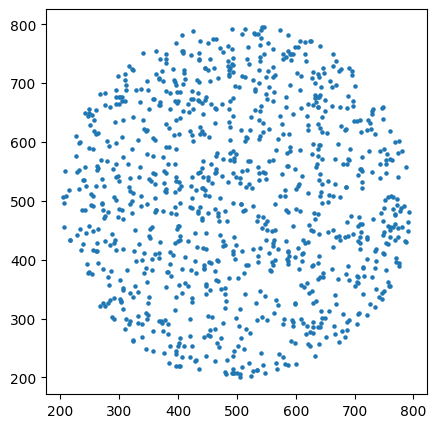

 44%|████▍     | 440/1000 [00:00<00:00, 8557.66it/s]


KeyboardInterrupt: 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.integrate import quad
from astropy.table import Table
import random
from tqdm import tqdm
from scipy.integrate import dblquad
random.seed(15)
np.random.seed(15)

# .evt install
hdul = fits.open('/home/yu/XRT/GRB190823A/processed_data/20934/sw00020934002xpcw3po_cl.evt')
EVENTS = hdul['EVENTS'].data
skyx = EVENTS['X']
skyy = EVENTS['Y']
rawx = EVENTS['RAWX']
rawy = EVENTS['RAWY']
time = EVENTS['time']
BADPIX = hdul['BADPIX'].data
badrawx = BADPIX['RAWX']
badrawy = BADPIX['RAWY']
badrawx=extended_bad_rawx
badrawy=extended_bad_rawy

GTI = hdul['GTI'].data
col = hdul['EVENTS'].columns

#### BAD RAW TO BAD SKY ####
def BADRAWtoBADSKY(start, stop):
    skyx_ex = skyx[(time>start) & (time<stop)]
    skyy_ex = skyy[(time>start) & (time<stop)]
    rawx_ex = rawx[(time>start) & (time<stop)]
    rawy_ex = rawy[(time>start) & (time<stop)]

    raws = np.vstack([rawx_ex, rawy_ex, np.ones_like(rawx_ex)]).T
    a, b, offsetx = np.linalg.lstsq(raws, skyx_ex, rcond=None)[0]
    c, d, offsety = np.linalg.lstsq(raws, skyy_ex, rcond=None)[0]
    badskyx = a*badrawx + b*badrawy + offsetx
    badskyy = c*badrawx + d*badrawy + offsety
    return badskyx, badskyy
start = GTI['START'][0]+300
badskyx, badskyy = BADRAWtoBADSKY(start, start+300)
badskyx = np.rint(badskyx).astype(int)
badskyy = np.rint(badskyy).astype(int)
badset = set(zip(badskyx, badskyy))

pairs = np.unique(np.column_stack([badskyx, badskyy]), axis=0)
badx_expanded, bady_expanded = pairs[:,0], pairs[:,1]

# 周囲の相対座標（3x3, 中心含む）
dx = [-1, 0, 1]
dy = [-1, 0, 1]

# 新しい座標をリストに貯める
xlist, ylist = [], []
for x, y in zip(badskyx, badskyy):
    for ddx in dx:
        for ddy in dy:
            xlist.append(x + ddx)
            ylist.append(y + ddy)

# 配列に変換
badx_expanded = np.array(xlist, dtype=int)
bady_expanded = np.array(ylist, dtype=int)
# 重複を除去
pairs = np.unique(np.column_stack([badx_expanded, bady_expanded]), axis=0)
badx_expanded, bady_expanded = pairs[:,0], pairs[:,1]
badset_expanded = set(zip(badx_expanded, bady_expanded))

#############################

# # # count-rate install (φ=0.001E^-2)
count_rate = np.load('/home/yu/XRT/count_rate_table.npy') #/s

# # # PI pdf install 
# PI_pdf = np.load('/home/yu/XRT/PI_map_norm.npy')

# general (0-600)
limit = 20


# # PSF
hdul_006 = fits.open('/home/yu/XRT/caldb/data/swift/xrt/cpf/psf/swxpsf20010101v006.fits')
PC_006 = hdul_006['PC_PSF_COEF'].data
parameters_6 = PC_006['COEF0']
def psf(r):
    p0 = parameters_6[0]
    p1 = parameters_6[1]
    p2 = parameters_6[2]
    p3 = parameters_6[3]
    psf = p0*np.exp(-(r**2/2/p1**2))+(1-p0)*(1+(r/p2)**2)**-p3
    return psf

def psf_xy(y, x):
    r=np.sqrt(x**2+y**2)
    return psf(r)

def psf_integral(r):
    p0 = parameters_6[0]
    p1 = parameters_6[1]
    p2 = parameters_6[2]
    p3 = parameters_6[3]
    psf = 2*np.pi*r*(p0*np.exp(-(r**2/2/p1**2))+(1-p0)*(1+(r/p2)**2)**-p3)
    return psf
total, _ = quad(psf_integral, 0, np.inf)
circleregion, _ = quad(psf_integral, 0, limit)
psfratio=circleregion/total
# print(psfratio)


x = np.linspace(-limit, limit, 2*limit+1)
y = np.linspace(-limit, limit, 2*limit+1)
X, Y = np.meshgrid(x, y)
R = np.hypot(X, Y)
psf_vals = np.zeros_like(R)

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        r = R[i, j]
        x0 = X[i, j]
        y0 = Y[i, j]
        if r < 10:
            val, _ = dblquad(
                psf_xy,
                x0 - 0.5, x0 + 0.5,
                lambda x: y0 - 0.5,
                lambda x: y0 + 0.5
            )
        else:
            val = psf(r)
        psf_vals[i, j] = val
# print(psf_vals.shape)
probability = np.where(R <= limit, psf_vals, np.nan)
nan_mask=np.isnan(probability)
prob_map_flat = np.nan_to_num(probability).flatten()
norm_prob_map_flat=prob_map_flat/np.sum(prob_map_flat)
#######################################################

import numpy as np
import matplotlib.pyplot as plt

def random_points_in_circle(n, R, cx=500.5, cy=500.5, seed=None):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2*np.pi, size=n)     # 角度を一様に
    r = R * np.sqrt(rng.uniform(0, 1, size=n))  # 半径は √u で補正
    x = cx + r * np.cos(theta)
    y = cy + r * np.sin(theta)
    return x, y

# 例: 半径10の円内に1000点
x_source, y_source = random_points_in_circle(1000, R=300)
x_source=np.rint(x_source).astype(int)
y_source=np.rint(y_source).astype(int)
plt.figure(figsize=(5,5))
plt.scatter(x_source, y_source, s=5)
plt.gca().set_aspect("equal")
plt.show()
#################################################################
inject_list = []
total_list = []
for x_source, y_source in zip(x_source, y_source):
    ## count_rate
    count_e3 = count_rate[y_source - 200][x_source - 200]
    rate_list = np.array([1])
    count_rate_list = count_e3*rate_list

    for h, rate in enumerate(count_rate_list):

        n = h+1
        for i in tqdm(range(1000)):
            # distribution
            exposure_time = 300 # s
            total_counts = (rate*exposure_time)
            # print(total_counts)
            total_counts = (rate*exposure_time)*psfratio
            # print(total_counts)
            inject_counts = np.random.poisson(lam=total_counts)
            inject_list.append(inject_counts)
            # print('N_events', inject_counts)

            # 多項分布で振り分け（各ピクセルに何個行くか）
            pixel_counts_flat = np.random.multinomial(inject_counts, norm_prob_map_flat)
            # 元の形（2D）に戻す
            pixel_counts = pixel_counts_flat.reshape(psf_vals.shape)
            pixel_counts = pixel_counts.astype(float)
            pixel_counts[nan_mask] = np.nan

            # print(len(pixel_counts))
            ########## badsky scan #############
            # pixel_counts[badskyy, badskyx] = np.nan
            # print(np.nansum(pixel_counts))


            
            # fig = plt.figure(figsize=(6.5,5))
            # ax = plt.gca()  # 現在のAxesを取得
            # plt.title(f'distribution plot in 300 s No.{i}', fontsize=20)
            # plt.xlabel('x axis (pixel)', fontsize = 17)
            # plt.ylabel('y axis (pixel)', fontsize = 17)
            # # 散布図の描画
            # sc = ax.scatter(X, Y, c=pixel_counts, cmap='viridis')
            # plt.colorbar(sc, label = 'entry')
            # # テキスト
            # plt.text(10, 18, f'total: {inject_counts}', fontsize =14)
            # plt.tick_params(labelsize =14)
            # plt.savefig(f'/home/yu/XRT/NGC1068/created/distribution_plot_in_300s_No.{i}.png')
            # plt.close()
            mask = (~np.isnan(pixel_counts)) & (pixel_counts != 0)
            non_nan_nonzero_coords = np.argwhere(mask)
            non_nan_nonzero_values = pixel_counts[mask]
            x_range = np.linspace(-limit, limit, pixel_counts.shape[1])  # 横方向（列数）
            y_range = np.linspace(-limit, limit, pixel_counts.shape[0])  # 縦方向（行数）

            # 各イベントの (x, y, t) を格納する配列を作成
            x_list = []
            y_list = []
        
            for coord, count in zip(non_nan_nonzero_coords, non_nan_nonzero_values):
                y_idx, x_idx = coord
                x = x_range[x_idx] + x_source
                y = y_range[y_idx] + y_source

                # 座標は badset と同じ座標系・型（整数）に揃える
                xi = int(x); yi = int(y)
                if (xi, yi) in badset_expanded:
                    continue
                c = int(count)
                x_list.extend([xi] * c)
                y_list.extend([yi] * c)
            
            x_array = np.array(x_list, dtype='>i2')
            
            # time distribution
        
            total = int(len(x_array))
            total_list.append(total)
inject_list=np.array(inject_list)
total_list=np.array(total_list)
# np.save(f'/home/yu/XRT/GRB190823A/processed_data/20934/w_filter/random100_100_inject_counts.npy', inject_list)
# np.save(f'/home/yu/XRT/GRB190823A/processed_data/20934/w_filter/random100_100_total_counts.npy', total_list)

Filename: /home/yu/XRT/GRB190823A/processed_data/20934/GTI1300_600_ex.img
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   (1000, 1000)   float32   


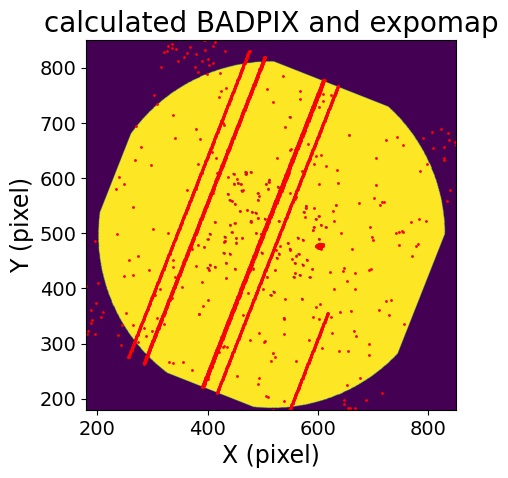

赤点数: 3279
expo=0 のピクセル数: 4536


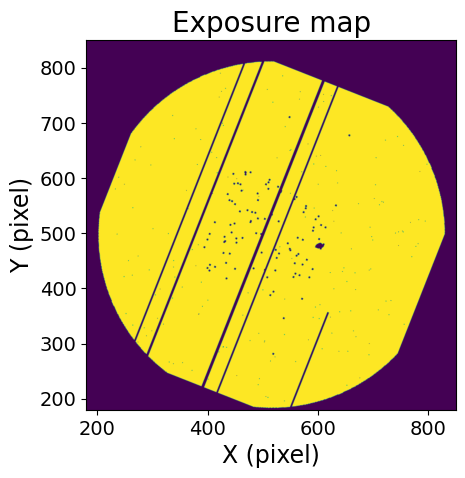

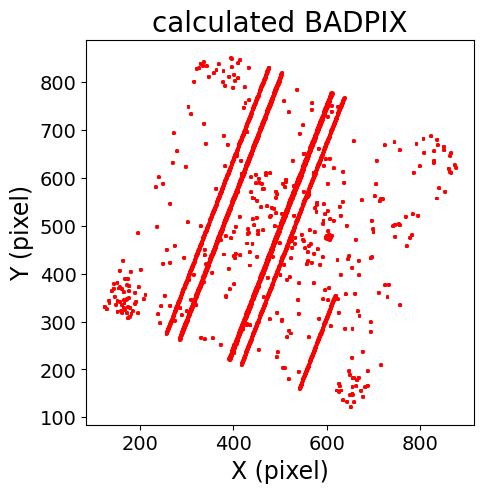

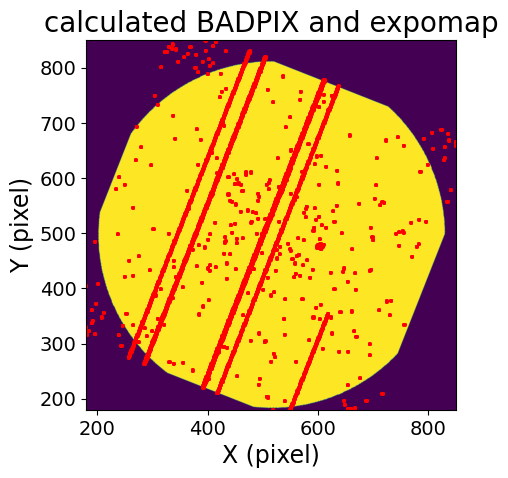

赤点数: 12934
expo=0 のピクセル数: 4536
14845


In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
expo = fits.open('/home/yu/XRT/GRB190823A/processed_data/20934/GTI1300_600_ex.img')
expo.info()
primary = expo['PRIMARY'].data
binary = (primary >= 10).astype(int) 
# plt.imshow(binary)
plt.imshow(primary, origin="lower", extent=[1, 1000, 1, 1000])
# plt.colorbar()
plt.scatter(badskyx, badskyy, marker='o',color='red', s=1, label='BADPIX')

plt.xlabel("X (pixel)", fontsize=17)
plt.ylabel("Y (pixel)", fontsize=17)
# plt.legend()
plt.title("calculated BADPIX and expomap", fontsize=20)
plt.xlim(180, 850)
plt.ylim(180, 850)
# plt.xlim(590, 620)
# plt.ylim(460, 490)
# plt.xlim(600, 620)
# plt.ylim(500, 530)
plt.tick_params(labelsize=14)
plt.show()

import numpy as np

# 1. 赤点のカウント
mask_bad = (300 <= badskyx) & (badskyx <= 700) & (300 <= badskyy) & (badskyy <= 700)
n_bad_in_square = np.count_nonzero(mask_bad)

# 2. expomap=0 のピクセル数
#    (300:700 がインデックスか座標かで注意)
exp_sub = primary[300:701, 300:701]  # 0始まりならこの範囲
n_zero_in_square = np.count_nonzero(exp_sub == 0)

print("赤点数:", n_bad_in_square)
print("expo=0 のピクセル数:", n_zero_in_square)

plt.title("Exposure map", fontsize=20)
plt.imshow(primary, origin="lower", extent=[1, 1000, 1, 1000])
# plt.colorbar()
plt.xlabel("X (pixel)", fontsize=17)
plt.ylabel("Y (pixel)", fontsize=17)
plt.tick_params(labelsize=14)
plt.xlim(180, 850)
plt.ylim(180, 850)
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(badx_expanded, bady_expanded, marker='o',color='red', s=1, label='BADPIX')
plt.xlabel("X (pixel)", fontsize=17)
plt.ylabel("Y (pixel)", fontsize=17)
# plt.legend()
plt.title("calculated BADPIX", fontsize=20)
# plt.xlim(180, 850)
# plt.ylim(180, 850)
# # plt.xlim(590, 620)
# # plt.ylim(460, 490)
# plt.xlim(600, 620)
# plt.ylim(500, 530)
# plt.xlim(500, 520)
# plt.ylim(500, 520)
plt.tick_params(labelsize=14)
plt.show()


plt.imshow(primary, origin="lower", extent=[1, 1000, 1, 1000])
# plt.colorbar()

plt.scatter(badx_expanded, bady_expanded, marker='o',color='red', s=1, label='BADPIX')

plt.xlabel("X (pixel)", fontsize=17)
plt.ylabel("Y (pixel)", fontsize=17)
# plt.legend()
plt.title("calculated BADPIX and expomap", fontsize=20)
plt.xlim(180, 850)
plt.ylim(180, 850)
# # plt.xlim(590, 620)
# # plt.ylim(460, 490)
# plt.xlim(600, 620)
# plt.ylim(500, 530)
# plt.xlim(500, 520)
# plt.ylim(500, 520)
plt.tick_params(labelsize=14)
plt.show()

import numpy as np

# 1. 赤点のカウント
xc, yc = 500.5, 500.5   # 円の中心
R = 300                 # 半径

dist2 = (badx_expanded - xc)**2 + (bady_expanded - yc)**2
mask_bad = dist2 <= R**2
n_bad_in_square = np.count_nonzero(mask_bad)

# 2. expomap=0 のピクセル数
#    (300:700 がインデックスか座標かで注意)
exp_sub = primary[300:701, 300:701]  # 0始まりならこの範囲
n_zero_in_square = np.count_nonzero(exp_sub == 0)

print("赤点数:", n_bad_in_square)
print("expo=0 のピクセル数:", n_zero_in_square)


pairs = np.unique(np.column_stack([badx_expanded, bady_expanded]), axis=0)
badx_expanded, bady_expanded = pairs[:,0], pairs[:,1]
print(len(badx_expanded))


Filename: /home/yu/XRT/GRB190823A/processed_data/20934/GTI1300_600_ex.img
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   (1000, 1000)   float32   


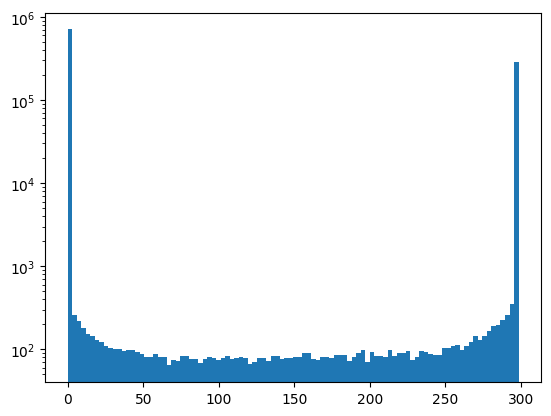

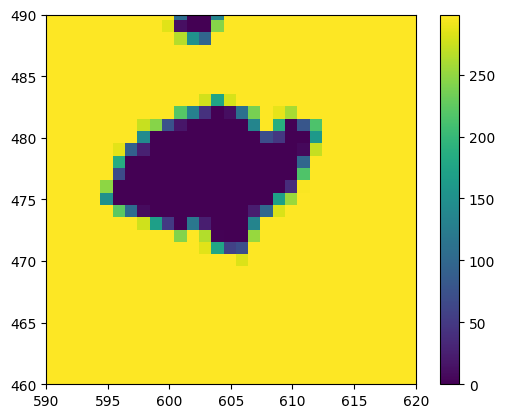

In [16]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
expo = fits.open('/home/yu/XRT/GRB190823A/processed_data/20934/GTI1300_600_ex.img')
expo.info()
primary = expo['PRIMARY'].data
# primary = np.where(1e2, primary==0, primary)
plt.hist(primary.flatten(), bins = 100)
plt.yscale('log')
plt.show()
# primary = np.log(primary)
# print(primary)
plt.imshow(primary, origin="lower", extent=[1, 1000, 1, 1000])
plt.xlim(590, 620)
plt.ylim(460, 490)
plt.colorbar()

Filename: /home/yu/XRT/caldb/data/swift/xrt/bcf/instrument/swxregion20010101v004.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  REGION_FOV    1 BinTableHDU     38   1R x 4C   [16A, E, E, E]   
  2  REGION_CAL    1 BinTableHDU     38   4R x 4C   [16A, E, E, E]   
  3  REGION_CORNER    1 BinTableHDU     36   8R x 3C   [16A, 3E, 3E]   
ColDefs(
    name = 'SHAPE'; format = '16A'
    name = 'DETX'; format = 'E'; unit = 'pixel'
    name = 'DETY'; format = 'E'; unit = 'pixel'
    name = 'R'; format = 'E'; unit = 'pixel'
)
[('circle', 307., 296., 314.)]
ColDefs(
    name = 'SHAPE'; format = '16A'
    name = 'DETX'; format = 'E'; unit = 'pixel'
    name = 'DETY'; format = 'E'; unit = 'pixel'
    name = 'R'; format = 'E'; unit = 'pixel'
)
[('circle',  37., 571., 50.) ('circle', 575., 562., 50.)
 ('circle',  38.,  27., 50.) ('circle', 580.,  19., 47.)]
ColDefs(
    name = 'SHAPE'; format = '16A'
    name = 'DETX'; format

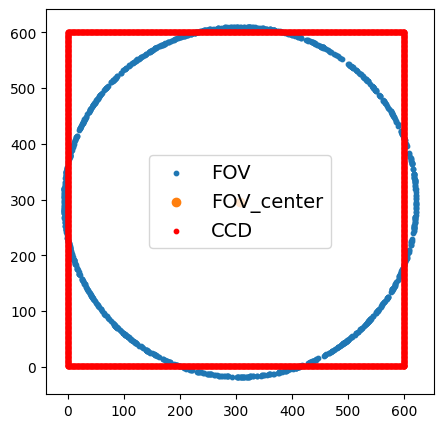

In [10]:
import random
from astropy.io import fits
import numpy as np 
import matplotlib.pyplot as plt
# .evt install
hdul = fits.open('/home/yu/XRT/caldb/data/swift/xrt/bcf/instrument/swxregion20010101v004.fits')
hdul.info()
fov_columns = hdul['REGION_FOV'].columns
fov_data = hdul['REGION_FOV'].data
print(fov_columns)
print(fov_data)

cal_columns = hdul['REGION_CAL'].columns
cal_data = hdul['REGION_CAL'].data
print(cal_columns)
print(cal_data)

corner_columns = hdul['REGION_CORNER'].columns
corner_data = hdul['REGION_CORNER'].data
print(corner_columns)
print(corner_data)


def circle(xc, yc, R):
    theta = [2*np.pi*random.random() for i in range (1000)]
    x = R*np.cos(theta)+xc
    y = R*np.sin(theta)+yc
    return x, y

def polygon(xarrays, yarrays):
    x_closed = np.concatenate([xarrays, xarrays[:, :1]], axis=1)
    y_closed = np.concatenate([yarrays, yarrays[:, :1]], axis=1)
    return x_closed, y_closed

fov_x, fov_y = circle(fov_data['DETX'], fov_data['DETY'], fov_data['R'])
cal_x1, cal_y1 = circle(cal_data['DETX'][0], cal_data['DETY'][0], cal_data['R'][0])
cal_x2, cal_y2 = circle(cal_data['DETX'][1], cal_data['DETY'][1], cal_data['R'][1])

cal_x3, cal_y3 = circle(cal_data['DETX'][2], cal_data['DETY'][2], cal_data['R'][2])
cal_x4, cal_y4 = circle(cal_data['DETX'][3], cal_data['DETY'][3], cal_data['R'][3])
triangles_x, triangles_y = polygon(corner_data['DETX'], corner_data['DETY'])

line0_x = np.array([1 for i in range(600)])
line0_y = np.array([1 for i in range(600)])
line1_x = np.linspace(1, 600, 600)
line1_y = np.linspace(1, 600, 600)
line2_x = np.array([600 for i in range(600)])
line2_y = np.array([600 for i in range(600)])
print(line1_x)

plt.figure(figsize=(5,5))
plt.scatter(fov_x, fov_y, s=10, label='FOV')
plt.scatter(fov_data['DETX'], fov_data['DETY'], label='FOV_center')
# plt.scatter(extended_bad_rawx, extended_bad_rawy, s=10, color='red')
# plt.scatter(cal_x1, cal_y1, s=10)
# plt.scatter(cal_x2, cal_y2, s=10)
# plt.scatter(cal_x3, cal_y3, s=10)
# plt.scatter(cal_x4, cal_y4, s=10)
plt.scatter(line0_x, line1_y, color='red', s=10, label='CCD')
plt.scatter(line1_x, line2_y, color='red', s=10)
plt.scatter(line2_x, line1_y, color='red', s=10)
plt.scatter(line1_x, line0_y, color='red', s=10)
plt.legend(fontsize=14)
# for i in range(len(triangles_x)):
#     plt.plot(triangles_x[i], triangles_y[i], markersize=1)
plt.show()

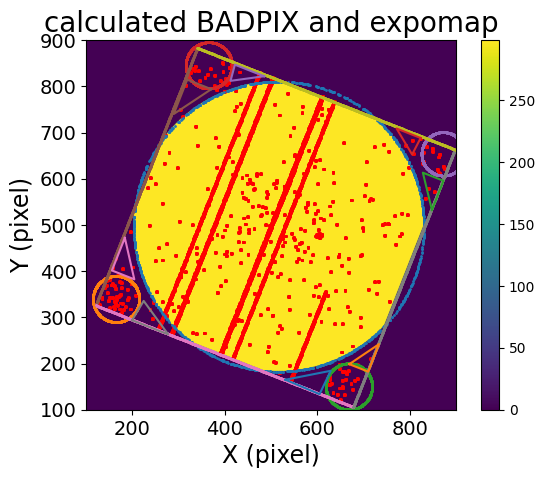

In [85]:
def BADRAWtoBADSKY(start, stop, badrawx_1, badrawy_1):
    skyx_ex = skyx[(time>start) & (time<stop)]
    skyy_ex = skyy[(time>start) & (time<stop)]
    rawx_ex = rawx[(time>start) & (time<stop)]
    rawy_ex = rawy[(time>start) & (time<stop)]

    raws = np.vstack([rawx_ex, rawy_ex, np.ones_like(rawx_ex)]).T
    a, b, offsetx = np.linalg.lstsq(raws, skyx_ex, rcond=None)[0]
    c, d, offsety = np.linalg.lstsq(raws, skyy_ex, rcond=None)[0]
    badskyx = a*badrawx_1 + b*badrawy_1 + offsetx
    badskyy = c*badrawx_1 + d*badrawy_1 + offsety
    return badskyx, badskyy

sky_fov_x, sky_fov_y = BADRAWtoBADSKY(start, start+300, fov_x, fov_y)
sky_cal_x1, sky_cal_y1 = BADRAWtoBADSKY(start, start+300, cal_x1, cal_y1)
sky_cal_x2, sky_cal_y2 = BADRAWtoBADSKY(start, start+300, cal_x2, cal_y2)
sky_cal_x3, sky_cal_y3 = BADRAWtoBADSKY(start, start+300, cal_x3, cal_y3)
sky_cal_x4, sky_cal_y4 = BADRAWtoBADSKY(start, start+300, cal_x4, cal_y4)
sky_triangles_x, sky_triangles_y = BADRAWtoBADSKY(start, start+300, triangles_x, triangles_y)
lv_x, lvy = BADRAWtoBADSKY(start, start+300, line0_x , line1_y)
uh_x, uh_y = BADRAWtoBADSKY(start, start+300, line1_x , line2_y)
rv_x, rv_y = BADRAWtoBADSKY(start, start+300, line2_x , line1_y)
dh_x, dh_y = BADRAWtoBADSKY(start, start+300, line1_x , line0_y)

plt.imshow(primary, origin="lower", extent=[1, 1000, 1, 1000])
plt.colorbar()

plt.scatter(badx_expanded, bady_expanded, marker='o',color='red', s=1, label='BADPIX')

plt.xlabel("X (pixel)", fontsize=17)
plt.ylabel("Y (pixel)", fontsize=17)
# plt.legend()
plt.title("calculated BADPIX and expomap", fontsize=20)
plt.xlim(100, 900)
plt.ylim(100, 900)
# # plt.xlim(590, 620)
# # plt.ylim(460, 490)
# plt.xlim(600, 620)
# plt.ylim(500, 530)
# plt.xlim(500, 520)
# plt.ylim(500, 520)
plt.tick_params(labelsize=14)
# plt.show()
# plt.figure(figsize=(5,5))
plt.scatter(sky_fov_x, sky_fov_y, s=1)
plt.scatter(sky_cal_x1, sky_cal_y1, s=1)
plt.scatter(sky_cal_x2, sky_cal_y2, s=1)
plt.scatter(sky_cal_x3, sky_cal_y3, s=1)
plt.scatter(sky_cal_x4, sky_cal_y4, s=1)
plt.scatter(lv_x, lvy, s=1)
plt.scatter(uh_x, uh_y, s=1)
plt.scatter(rv_x, rv_y, s=1)
plt.scatter(dh_x, dh_y, s=1)
for i in range(len(sky_triangles_x)):
    plt.plot(sky_triangles_x[i], sky_triangles_y[i], markersize=1)
# plt.xlim(350, 450)
# plt.ylim(700, 800)
plt.show()

Filename: /home/yu/XRT/caldb/data/swift/xrt/bcf/badpix/swxonboardbp20090821v004.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  PCBADPIX      1 BinTableHDU     63   226R x 7C   [D, I, I, I, I, I, 16X]   
  2  IMBADPIX      1 BinTableHDU     63   230R x 7C   [D, I, I, I, I, I, 16X]   
  3  WTBADPIX      1 BinTableHDU     63   10R x 7C   [D, I, I, I, I, I, 16X]   


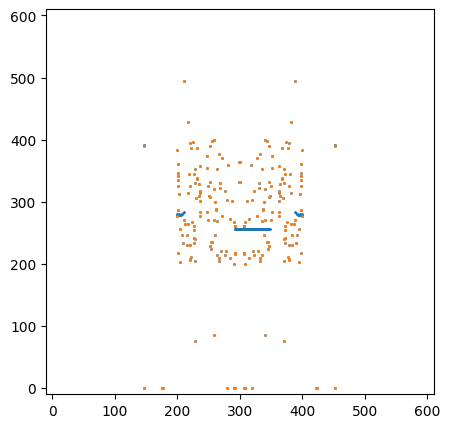

In [70]:
bad = fits.open('/home/yu/XRT/caldb/data/swift/xrt/bcf/badpix/swxbadpix20090821v005.fits')
bad_pc = bad['PCBADPIX']
# print(bad_pc['RAWX'])
onboard = fits.open('/home/yu/XRT/caldb/data/swift/xrt/bcf/badpix/swxonboardbp20090821v004.fits')
onboard.info()
onboard_pc = onboard['PCBADPIX']

plt.figure(figsize=(5,5))
plt.scatter(bad_pc.data['RAWX'], bad_pc.data['RAWY'], s=1)
plt.scatter(onboard_pc.data['RAWX'], onboard_pc.data['RAWY'], s=1)
plt.xlim(-10, 610)
plt.ylim(-10, 610)
plt.show()

Filename: /home/yu/XRT/caldb/data/swift/xrt/bcf/instrument/swxhkranges6_20010101v011.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  ATTRANGE      1 BinTableHDU     33   5R x 3C   [16A, 30A, 1I]   
  2  INSTRANGE     1 BinTableHDU     35   9R x 3C   [16A, 30A, 1I]   
  3  SACRANGE      1 BinTableHDU     35   3R x 3C   [16A, 30A, 1I]   
ColDefs(
    name = 'PARNAME'; format = '16A'
    name = 'RANGE'; format = '30A'
    name = 'SYNTAX'; format = '1I'
)
